In [ ]:
from matplotlib.animation import FFMpegWriter
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 100.0


ruta_modulo = os.path.abspath("../build/Release") 
if ruta_modulo not in sys.path: 
    sys.path.append(ruta_modulo)

import motor_mpd_cpp


Nr, Nz = 30, 80      
r_c, L_c = 0.339, 3.143 
r_a_base, L_a = 2.653, 4.490 
r_a_max = 5.0
L_sim = 6.5
dt = 5e-10
N_iones = 1000
n_e = 2.27e19          # Densidad de plasma (electrones/m^3)
carga_e = 1.602e-19    # Carga elemental (C)

R_1D = np.linspace(0, r_a_max, Nr)
Z_1D = np.linspace(0, L_sim, Nz)


R, Z = np.meshgrid(R_1D, Z_1D, indexing='ij')


Bz = np.zeros_like(R) 
Br = np.zeros_like(R)
Er = np.zeros_like(R)
Ez = np.zeros_like(R)


dr_celda_cm = r_a_max / (Nr - 1)
n_celdas_vaina = 3.0
radio_atraccion = r_c + (n_celdas_vaina * dr_celda_cm)
E_vaina = 0.5 
mascara_vaina = (Z >= 0.1) & (Z <= L_c) & (R >= r_c) & (R <= radio_atraccion)
Er[mascara_vaina] = -E_vaina * (1.0 - (Z[mascara_vaina] / L_c))


E_max_z = 10.0 
mascara_punta = (Z >= L_c) & (Z <= L_a) & (R >= 0.0) & (R <= r_c)
Ez[mascara_punta] = -E_max_z


Parametro_Hall = 1.5
corriente_A = 222.0

# Campo magnético calculado directamente en malla uniforme de Python
B0 = 0.5
a_coil = 4.0

Bz_campo = B0 / np.power(1.0 + np.power(Z / a_coil, 2), 1.5)
dBz_dz = -3.0 * B0 * Z / (a_coil**2 * np.power(1.0 + np.power(Z / a_coil, 2), 2.5))
Br_campo = -0.5 * R * dBz_dz

Br_campo_c = np.ascontiguousarray(Br_campo)
Bz_campo_c = np.ascontiguousarray(Bz_campo)

lorentz = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)  
lorentz.calcular_tensores(corriente_A, Parametro_Hall, L_c, R, Z, Br_campo_c, Bz_campo_c)

# 2. Extraemos las matrices puras
Fz_base = np.nan_to_num(lorentz.Fz)
Fr_base = np.nan_to_num(lorentz.Fr)

# 3. Definimos máscara y escalamos (Ahora Fz_base ya existe)
epsilon = 0.05
mascara_empuje = (Z >= 0.0) & (Z <= L_c) & (R >= (radio_atraccion)) & (R <= r_a_base)
factor_escalado = 1.0 / (carga_e * n_e)

Ez[mascara_empuje] = Fz_base[mascara_empuje] * factor_escalado
Er[mascara_empuje] = -(Fr_base[mascara_empuje]) * factor_escalado


# Compactamos matrices
Ez = np.ascontiguousarray(Ez)
Er = np.ascontiguousarray(Er)
Bz = np.ascontiguousarray(Bz)
Br = np.ascontiguousarray(Br)

# Geometría de la pared del ánodo
limite_pared = r_a_base + 0.15 * np.power(Z_1D, 2.0)
limite_pared = np.clip(limite_pared, 0, r_a_max)
limite_pared_c = np.ascontiguousarray(limite_pared)

# =========================
# 3. INICIALIZAR SIMULACIÓN (CON ECUACIÓN DE VELOCIDAD SÓNICA)
# =========================
Te_eV = 1.5 

# Propiedades termodinámicas del gas de inyección (Argón Neutro)
T_gas_K = 300.0          # Temperatura de inyección en Kelvin
gamma = 5.0 / 3.0        # Índice adiabático para gas monoatómico (Argón)
k_B = 1.38e-23           # Constante de Boltzmann (J/K)
masa_ion_kg = 6.63e-26   # Masa del átomo de Argón (kg)

# Ecuación paramétrica de la velocidad inicial (Velocidad del sonido local)
u_z_inicial = np.sqrt((gamma * k_B * T_gas_K) / masa_ion_kg)



# Inicializamos el simulador
solver = motor_mpd_cpp.SimuladorPIC(N_iones, Te_eV, r_c, r_a_max, L_c, L_a, Nr)

solver.inicializar_particulas(15000.0, r_a_base) 

# Leemos posición inicial (solo del primer ion para probar)
pos_ini = solver.obtener_posiciones_rz()
print(f"Posición inicial Ion 0: R={pos_ini[0,0]:.4f}, Z={pos_ini[0,1]:.4f}")

# Damos 10 pasos
for _ in range(10):
    solver.avanzar_paso_temporal_boris(dt, Ez, Er, Bz, Br, limite_pared_c, L_sim, Nz)

# Leemos posición final
pos_fin = solver.obtener_posiciones_rz()
print(f"Posición final Ion 0:   R={pos_fin[0,0]:.4f}, Z={pos_fin[0,1]:.4f}")

# Verificamos si hubo cambio
if abs(pos_fin[0,1] - pos_ini[0,1]) > 0:
    print("¡ÉXITO! Los iones se están moviendo.")
else:
    print("ERROR: Los iones siguen estáticos.")

solver.inicializar_particulas(u_z_inicial, r_a_base) 




fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='white')
fig.subplots_adjust(bottom=0.22)
ax1.set_xlim(0, L_sim)
ax1.set_ylim(0, r_a_max)
ax1.set_xlabel('Posición Axial Z (cm)', fontsize=12)
ax1.set_ylabel('Radio R (cm)', fontsize=12)

ax1.fill_between([0, L_c], [0, 0], [r_c, r_c], color='dimgray', label='Cátodo')
ax1.fill_between(Z_1D, limite_pared, r_a_max, color='darkslategray', alpha=0.8, label='Ánodo')
ax1.axvline(x=L_c, color='red', linestyle='--', alpha=0.5, label='Punta (Z=L_c)')

# Contenedores para la animación
scat_vivos = ax1.scatter([], [], color='cyan', s=10, zorder=5, label='En tránsito')
scat_barril = ax1.scatter([], [], color='red', s=15, zorder=6, label='Colisión Barril')
scat_punta = ax1.scatter([], [], color='purple', s=20, zorder=6, label='Colisión Punta')
scat_escape = ax1.scatter([], [], color='lime', s=10, zorder=5, label='Eyectados')
# Añade este nuevo scatter a tus contenedores
scat_anodo = ax1.scatter([], [], color='gray', s=15, zorder=6, label='Colisión Ánodo')
#

ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=8,
           frameon=True, framealpha=1.0, edgecolor='gray')
titulo = ax1.set_title('Iniciando Simulación Híbrida...', fontsize=14, fontweight='bold', pad=8)


def update(frame):
    for _ in range(2500):
        # Alimentamos a Boris con los campos calculados en Python
        solver.avanzar_paso_temporal_boris(dt, Ez, Er, Bz, Br, limite_pared_c, L_sim, Nz)

    pos = solver.obtener_posiciones_rz()
    estados = solver.obtener_estados()
    
    Zp = pos[:, 1] * 100.0
    Rp = pos[:, 0] * 100.0
    
    m_vivos = estados == 0
    m_barril = estados == 1
    m_punta = estados == 2
    m_escape = estados == 3
    m_anodo = estados == 4  # <-- 1. Añadimos la máscara para el estado 4
    
    scat_vivos.set_offsets(np.column_stack((Zp[m_vivos], Rp[m_vivos])))
    scat_barril.set_offsets(np.column_stack((Zp[m_barril], Rp[m_barril])))
    scat_punta.set_offsets(np.column_stack((Zp[m_punta], Rp[m_punta])))
    scat_escape.set_offsets(np.column_stack((Zp[m_escape], Rp[m_escape])))
    scat_anodo.set_offsets(np.column_stack((Zp[m_anodo], Rp[m_anodo]))) # <-- 2. Actualizamos los puntos grises

    tiempo_us = (frame * 500 * dt) * 1e6
    
    # <-- 3. Añadimos el contador del ánodo al título
    titulo.set_text(f"t = {tiempo_us:.2f} μs | Vivos: {np.sum(m_vivos)} | Escape: {np.sum(m_escape)} | "
                    f"Punta: {np.sum(m_punta)} | Barril: {np.sum(m_barril)} | Ánodo: {np.sum(m_anodo)}")
    
    # <-- 4. Retornamos scat_anodo para que FuncAnimation lo redibuje
    return scat_vivos, scat_barril, scat_punta, scat_escape, scat_anodo, titulo


# durante 300 cuadros (frames) para generar el movimiento.
anim = FuncAnimation(fig, update, frames=300, interval=40, blit=True)


print("Generando animación GIF... ¡paciencia!")
anim.save("lluvia_iones_mpd.gif", writer='pillow', fps=20) 

print("¡Listo! El archivo 'lluvia_iones_mpd.gif' ya debería tener el movimiento.")

# Cerramos la figura para liberar memoria
plt.close(fig)


display(HTML(anim.to_jshtml()))

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import matplotlib
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
matplotlib.rcParams['animation.embed_limit'] = 100.0


ruta_modulo = os.path.abspath("../build/Release") 
if ruta_modulo not in sys.path: 
    sys.path.append(ruta_modulo)

import motor_mpd_cpp


Nr, Nz = 30, 80      
r_c, L_c = 0.339, 3.143 # 
r_a_base, L_a = 2.653, 4.490 #
r_a_max = 5.0
L_sim = 6.5
dt = 5e-10
N_iones = 1000

R_1D = np.linspace(0, r_a_max, Nr)
Z_1D = np.linspace(0, L_sim, Nz)


R, Z = np.meshgrid(R_1D, Z_1D, indexing='ij')


Bz = np.zeros_like(R) 
Br = np.zeros_like(R)
Er = np.zeros_like(R)
Ez = np.zeros_like(R)



# 1. Definimos la magnitud máxima de la fuerza inventada
# 5000 V/m es un buen punto de partida para aplastar los iones visiblemente
E_max = 0.5 


mascara_region = (Z >= 0.1) & (Z <= L_c) & (R >= r_c) & (R <= 0.8)


Er[mascara_region] = -E_max * (1.0 - (Z[mascara_region] / L_c))



# 1. Definimos la magnitud de la fuerza de succión hacia atrás
E_max_z = 10.0 # V/m (Un valor brutal para vencer la inercia axial)

# 2. Creamos la máscara para la zona central aguas abajo del cátodo
mascara_punta = (Z >= L_c) & (Z <= L_a) & (R >= 0.0) & (R <= r_c)

# 3. Aplicamos la fuerza SOLO en esa región
# El signo negativo asegura que la fuerza apunte hacia atrás (-Z)
Ez[mascara_punta] = -E_max_z

Parametro_Hall = 1.5
corriente_A = 222.0 


campo = motor_mpd_cpp.CampoMagnetico(Nr, Nz)
campo.calcular_campo_aplicado(0.5, L_c, L_a, r_c, r_a_max, True)

lorentz = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)
lorentz.calcular_tensores(corriente_A, Parametro_Hall, L_c, R, Z, campo.Br, campo.Bz)


Fz_base = np.nan_to_num(lorentz.Fz)
Fr_base = np.nan_to_num(lorentz.Fr)


epsilon = 0.05
mascara_empuje = (Z >= 0.0) & (Z <= L_c) & (R >= (0.8 + epsilon)) & (R <= r_a_base)


factor_escalado = 0.275 


Ez[mascara_empuje] = Fz_base[mascara_empuje] * factor_escalado
Er[mascara_empuje] = np.abs(Fr_base[mascara_empuje]) * factor_escalado


# -----------------------------------------------

# Las matrices deben ser contiguas en memoria para que C++ las lea sin colapsar
Ez = np.ascontiguousarray(Ez)
Er = np.ascontiguousarray(Er)
Bz = np.ascontiguousarray(Bz)
Br = np.ascontiguousarray(Br)

# Geometría de la pared del ánodo
limite_pared = r_a_base + 0.15 * np.power(Z_1D, 2.0)
limite_pared = np.clip(limite_pared, 0, r_a_max)
limite_pared_c = np.ascontiguousarray(limite_pared)


Te_eV = 1.5 

# Propiedades termodinámicas del gas de inyección (Argón Neutro)
T_gas_K = 300.0          # Temperatura de inyección en Kelvin
gamma = 5.0 / 3.0        # Índice adiabático para gas monoatómico (Argón)
k_B = 1.38e-23           # Constante de Boltzmann (J/K)
masa_ion_kg = 6.63e-26   # Masa del átomo de Argón (kg)

# Ecuación paramétrica de la velocidad inicial (Velocidad del sonido local)
u_z_inicial = np.sqrt((gamma * k_B * T_gas_K) / masa_ion_kg)




# Inicializamos el simulador
solver = motor_mpd_cpp.SimuladorPIC(N_iones, Te_eV, r_c, r_a_max, L_c, L_a, Nr)

solver.inicializar_particulas(15000.0, r_a_base) 

# Leemos posición inicial (solo del primer ion para probar)
pos_ini = solver.obtener_posiciones_rz()
print(f"Posición inicial Ion 0: R={pos_ini[0,0]:.4f}, Z={pos_ini[0,1]:.4f}")

# Damos 10 pasos
for _ in range(10):
    solver.avanzar_paso_temporal_boris(dt, Ez, Er, Bz, Br, limite_pared_c, L_sim, Nz)

# Leemos posición final
pos_fin = solver.obtener_posiciones_rz()
print(f"Posición final Ion 0:   R={pos_fin[0,0]:.4f}, Z={pos_fin[0,1]:.4f}")

# Verificamos si hubo cambio
if abs(pos_fin[0,1] - pos_ini[0,1]) > 0:
    print("¡ÉXITO! Los iones se están moviendo.")
else:
    print("ERROR: Los iones siguen estáticos.")

solver.inicializar_particulas(u_z_inicial, r_a_base)





ANCHO_CM = 8.8         
ANCHO_IN = ANCHO_CM / 2.54
ALTO_IN  = ANCHO_IN * 0.65  
DPI      = 300
FONTSIZE = 8
TICKSIZE = 7

plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif'],
    'font.size':        FONTSIZE,
    'axes.labelsize':   FONTSIZE,
    'axes.titlesize':   FONTSIZE,
    'xtick.labelsize':  TICKSIZE,
    'ytick.labelsize':  TICKSIZE,
    'axes.linewidth':   0.6,
    'xtick.major.width':0.6,
    'ytick.major.width':0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi':       DPI,
})

# --- Definir los frames a capturar ---
# dt=5e-10 s, 4000 pasos por frame de animación
PASOS_POR_FRAME = 4000
TOTAL_FRAMES    = 300

# t_final_sim = TOTAL_FRAMES * PASOS_POR_FRAME * dt
# = 300 * 4000 * 5e-10 = 6e-4 s = 600 μs
# Ajusta los porcentajes según tus tiempos reales de estado estacionario
snapshots = {
    'a': {'frame': 0,                          'label': r'$t = 0.0\,\mu s$'},
    'b': {'frame': int(TOTAL_FRAMES * 0.25),   'label': r'$t \approx 25\%$'},
    'c': {'frame': int(TOTAL_FRAMES * 0.33),   'label': r'$t \approx 33\%$'},
    'd': {'frame': int(TOTAL_FRAMES * 0.90),   'label': r'$t \approx 90\%$ (Estado Estacionario)'},
}


def dibujar_panel(ax, pos_array, estados_array, frame_idx, label_str):
    """
    Dibuja el estado de la simulación en un eje dado.
    pos_array y estados_array son los datos ya calculados para ese frame.
    """
    ax.set_facecolor('white')
    ax.set_xlim(0, L_sim)
    ax.set_ylim(0, r_a_max)


    ax.fill_between([0, L_c], [0, 0], [r_c, r_c],
                    color='dimgray')
    ax.fill_between(Z_1D, limite_pared, r_a_max,
                    color='darkslategray', alpha=0.8)
    ax.axvline(x=L_c, color='red', linestyle='--',
               alpha=0.5, linewidth=0.8)


    Zp = pos_array[:, 1] * 100.0  
    Rp = pos_array[:, 0] * 100.0

    m_vivos  = estados_array == 0
    m_barril = estados_array == 1
    m_punta  = estados_array == 2
    m_escape = estados_array == 3

    if m_vivos.any():
        ax.scatter(Zp[m_vivos],  Rp[m_vivos],
                   color='cyan',   s=2, zorder=5, linewidths=0)
    if m_barril.any():
        ax.scatter(Zp[m_barril], Rp[m_barril],
                   color='red',    s=3, zorder=6, linewidths=0)
    if m_punta.any():
        ax.scatter(Zp[m_punta],  Rp[m_punta],
                   color='purple', s=4, zorder=6, linewidths=0)
    if m_escape.any():
        ax.scatter(Zp[m_escape], Rp[m_escape],
                   color='lime',   s=2, zorder=5, linewidths=0)


    vivos_n  = np.sum(m_vivos)
    escape_n = np.sum(m_escape)
    punta_n  = np.sum(m_punta)
    barril_n = np.sum(m_barril)

    info_txt = (f"En tránsito: {vivos_n}\n"
                f"Eyectados: {escape_n}\n"
                f"Col. Punta: {punta_n}\n"
                f"Col. Barril: {barril_n}")

    ax.text(0.02, 0.97, info_txt,
            transform=ax.transAxes,
            fontsize=6, verticalalignment='top',
            horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='gray', alpha=0.85, linewidth=0.5))



    ax.set_xlabel('Posición Axial Z (cm)', fontsize=FONTSIZE)
    ax.set_ylabel('Radio R (cm)',          fontsize=FONTSIZE)





solver.inicializar_particulas(u_z_inicial, r_a_base)

capturas = {}   
frames_objetivo = {v['frame'] for v in snapshots.values()}
frame_max = max(frames_objetivo)

print(f"Avanzando simulación hasta frame {frame_max}...")
for frame_actual in range(frame_max + 1):

    if frame_actual in frames_objetivo:
        pos    = solver.obtener_posiciones_rz().copy()
        estados = solver.obtener_estados().copy()
        capturas[frame_actual] = (pos, estados)
        t_us = frame_actual * PASOS_POR_FRAME * dt * 1e6
        print(f"  ✓ Frame {frame_actual} capturado → t = {t_us:.2f} μs")

    if frame_actual < frame_max:
        for _ in range(PASOS_POR_FRAME):
            solver.avanzar_paso_temporal_boris(
                dt, Ez, Er, Bz, Br, limite_pared_c, L_sim, Nz)




keys = ['a', 'b', 'c', 'd']

for key in keys:
    meta        = snapshots[key]
    frame_idx   = meta['frame']
    label_str   = meta['label']
    pos, estados = capturas[frame_idx]

    t_us = frame_idx * PASOS_POR_FRAME * dt * 1e6
    nombre = f"snapshot_{t_us:.1f}us.png"

    fig, ax = plt.subplots(figsize=(ANCHO_IN, ALTO_IN),
                           facecolor='white')
    fig.subplots_adjust(left=0.12, right=0.97, top=0.97, bottom=0.15)

    dibujar_panel(ax, pos, estados, frame_idx, label_str)

    fig.savefig(nombre, dpi=DPI, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.close(fig)
    print(f"  Guardado: {nombre}")




elementos_leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dimgray',
           markersize=6, label='Cátodo'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='darkslategray',
           markersize=6, label='Ánodo'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=1,
           label=r'Punta del cátodo ($Z = L_c$)'),
    matplotlib.patches.Patch(facecolor='yellow', alpha=0.4,
                             label='Zona de retorno'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan',
           markersize=5, label='En tránsito'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=5, label='Colisión barril'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple',
           markersize=5, label='Colisión punta'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lime',
           markersize=5, label='Eyectados'),
]

fig_leg, ax_leg = plt.subplots(figsize=(ANCHO_IN * 2, 0.55),
                                facecolor='white')
ax_leg.axis('off')
ax_leg.legend(handles=elementos_leyenda,
              loc='center', ncol=4,
              fontsize=7, frameon=True,
              framealpha=1.0, edgecolor='gray',
              handlelength=1.5, handletextpad=0.5,
              columnspacing=1.0)

fig_leg.savefig('leyenda.png', dpi=DPI, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.close(fig_leg)
print("  Guardado: leyenda.png")
print("\n¡Listo! Archivos generados para LaTeX.")

Posición inicial Ion 0: R=0.0159, Z=-0.0383
Posición final Ion 0:   R=0.0159, Z=-0.0382
¡ÉXITO! Los iones se están moviendo.
Avanzando simulación hasta frame 270...
  ✓ Frame 0 capturado → t = 0.00 μs
  ✓ Frame 75 capturado → t = 150.00 μs
  ✓ Frame 99 capturado → t = 198.00 μs
  ✓ Frame 270 capturado → t = 540.00 μs
  Guardado: snapshot_0.0us.png
  Guardado: snapshot_150.0us.png
  Guardado: snapshot_198.0us.png
  Guardado: snapshot_540.0us.png
  Guardado: leyenda.png

¡Listo! Archivos generados para LaTeX.


Bobina normal

Corriendo barrido paramétrico...


  0%|          | 0/13 [00:00<?, ?it/s]

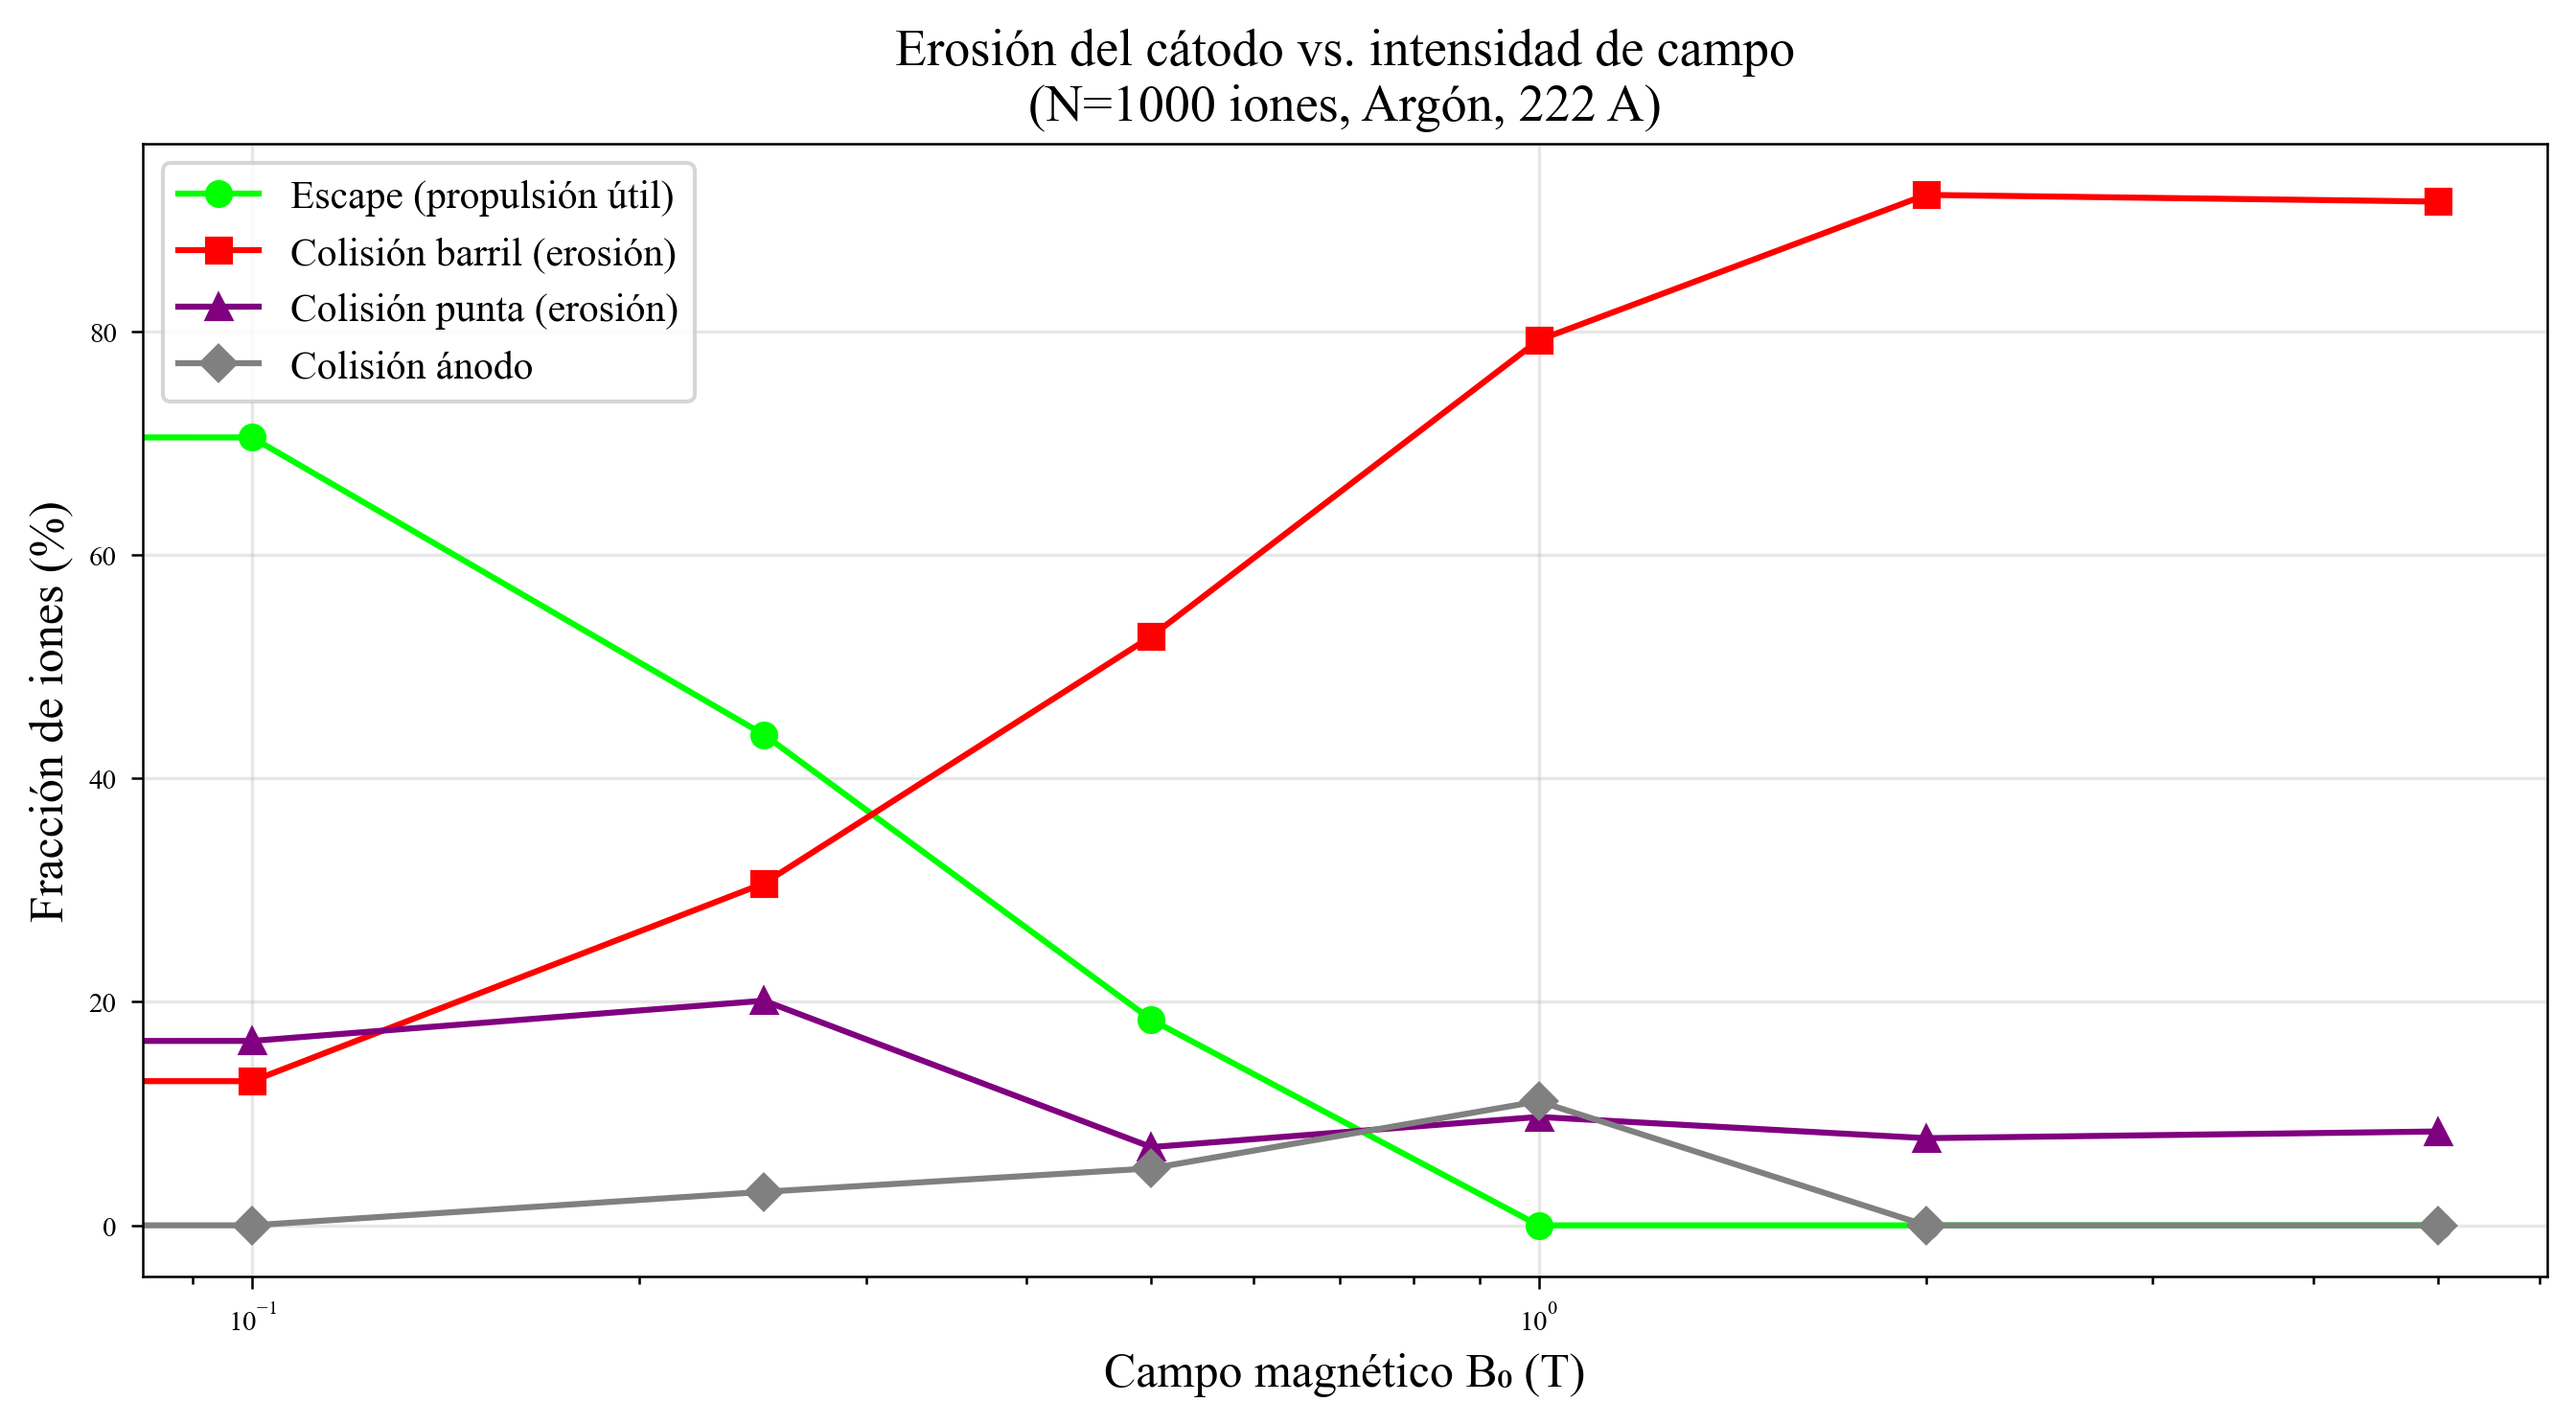


B0 (T)     Escape %     Barril %     Punta %      Ánodo %   
--------------------------------------------------------
-5.00      0.0          13.4         8.8          77.8      
-2.00      0.0          13.3         9.3          77.4      
-1.00      11.7         13.9         10.5         63.9      
-0.50      76.0         15.1         8.9          0.0       
-0.25      78.4         13.2         8.4          0.0       
-0.10      75.2         14.8         10.0         0.0       
0.00       78.6         14.4         7.0          0.0       
0.10       70.5         12.9         16.5         0.0       
0.25       43.9         30.6         20.1         3.0       
0.50       18.4         52.7         7.0          5.1       
1.00       0.0          79.2         9.7          11.1      
2.00       0.0          92.2         7.8          0.0       
5.00       0.0          91.6         8.4          0.0       


In [ ]:

from tqdm.notebook import tqdm

# Constantes (por si la celda se corre de forma aislada)
carga_e = 1.602e-19    # C
n_e = 2.27e19          # electrones/m^3

def correr_simulacion(B0_val, n_pasos=900_000):  # 900k ≈ 11.5 cm de viaje
    ...
    """
    Corre la simulación completa para un valor de B0 dado.
    Devuelve diccionario con porcentajes de cada estado final.
    """
    a_coil = 4.0


    Er_local = np.zeros_like(R)
    Ez_local = np.zeros_like(R)

    # Pre-vaina (no cambia con B0)
    dr_celda_cm = r_a_max / (Nr - 1)
    radio_atraccion = r_c + (3.0 * dr_celda_cm)
    E_vaina = 0.5
    mascara_vaina = (Z >= 0.1) & (Z <= L_c) & (R >= r_c) & (R <= radio_atraccion)
    Er_local[mascara_vaina] = -E_vaina * (1.0 - (Z[mascara_vaina] / L_c))

    # Succión de punta (no cambia con B0)
    E_max_z = 10.0
    mascara_punta = (Z >= L_c) & (Z <= L_a) & (R >= 0.0) & (R <= r_c)
    Ez_local[mascara_punta] = -E_max_z

    # Campo magnético calculado en la malla de Python (cambia con B0)
    Bz_c = B0_val / np.power(1.0 + np.power(Z / a_coil, 2), 1.5)
    dBz_dz = -3.0 * B0_val * Z / (a_coil**2 * np.power(1.0 + np.power(Z / a_coil, 2), 2.5))
    Br_c = -0.5 * R * dBz_dz

    # Lorentz (cambia con B0)
    lorentz_local = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)
    lorentz_local.calcular_tensores(corriente_A, Parametro_Hall, L_c, R, Z,
                                    np.ascontiguousarray(Br_c),
                                    np.ascontiguousarray(Bz_c))

    Fz_b = np.nan_to_num(lorentz_local.Fz)
    Fr_b = np.nan_to_num(lorentz_local.Fr)

    factor_escalado = 1.0 / (carga_e * n_e)
    mascara_empuje = (Z >= 0.0) & (Z <= L_c) & (R >= radio_atraccion) & (R <= r_a_base)
    Ez_local[mascara_empuje] = Fz_b[mascara_empuje] * factor_escalado
    Er_local[mascara_empuje] = Fr_b[mascara_empuje] * factor_escalado   # sin el menos

    # Compactar
    Ez_c = np.ascontiguousarray(Ez_local)
    Er_c = np.ascontiguousarray(Er_local)
    Bz_sim = np.ascontiguousarray(np.zeros_like(R))  # Bz en Boris = 0 por ahora
    Br_sim = np.ascontiguousarray(np.zeros_like(R))  # Br en Boris = 0 por ahora

    # --- 2. Inicializar partículas ---
    solver_local = motor_mpd_cpp.SimuladorPIC(N_iones, Te_eV, r_c, r_a_max, L_c, L_a, Nr)
    solver_local.inicializar_particulas(u_z_inicial, r_a_base)

    # --- 3. Correr simulación ---
    for _ in range(n_pasos):
        solver_local.avanzar_paso_temporal_boris(dt, Ez_c, Er_c, Bz_sim, Br_sim,
                                                  limite_pared_c, L_sim, Nz)

    # --- 4. Recoger resultados ---
    estados = solver_local.obtener_estados()
    total = len(estados)
    return {
        "B0":      B0_val,
        "escape":  100.0 * np.sum(estados == 3) / total,
        "barril":  100.0 * np.sum(estados == 1) / total,
        "punta":   100.0 * np.sum(estados == 2) / total,
        "anodo":   100.0 * np.sum(estados == 4) / total,
        "vivos":   100.0 * np.sum(estados == 0) / total,
    }

# --- Valores de B0 a barrer ---
valores_B0 = [-5.0, -2.0, -1.0, -0.50, -0.25, -0.10, 0.0, 0.10, 0.25, 0.50, 1.0, 2.0, 5.0]


print("Corriendo barrido paramétrico...")
resultados = [correr_simulacion(b) for b in tqdm(valores_B0)]

# --- Graficar ---
B0s      = [r["B0"]     for r in resultados]
escape_p = [r["escape"] for r in resultados]
barril_p = [r["barril"] for r in resultados]
punta_p  = [r["punta"]  for r in resultados]
anodo_p  = [r["anodo"]  for r in resultados]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.plot(B0s, escape_p, 'o-', color='lime',   label='Escape (propulsión útil)')
ax.plot(B0s, barril_p, 's-', color='red',    label='Colisión barril (erosión)')
ax.plot(B0s, punta_p,  '^-', color='purple', label='Colisión punta (erosión)')
ax.plot(B0s, anodo_p,  'D-', color='gray',   label='Colisión ánodo')

ax.set_xlabel('Campo magnético B₀ (T)', fontsize=12)
ax.set_ylabel('Fracción de iones (%)', fontsize=12)
ax.set_title('Erosión del cátodo vs. intensidad de campo\n(N=1000 iones, Argón, 222 A)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')  # escala log porque los valores van de 0.1 a 5 T
plt.tight_layout()
plt.show()

# Imprimir tabla resumen
print(f"\n{'B0 (T)':<10} {'Escape %':<12} {'Barril %':<12} {'Punta %':<12} {'Ánodo %':<10}")
print("-" * 56)
for r in resultados:
    print(f"{r['B0']:<10.2f} {r['escape']:<12.1f} {r['barril']:<12.1f} {r['punta']:<12.1f} {r['anodo']:<10.1f}")

probando topologías

Corriendo barrido HTS localizado...


  0%|          | 0/14 [00:00<?, ?it/s]

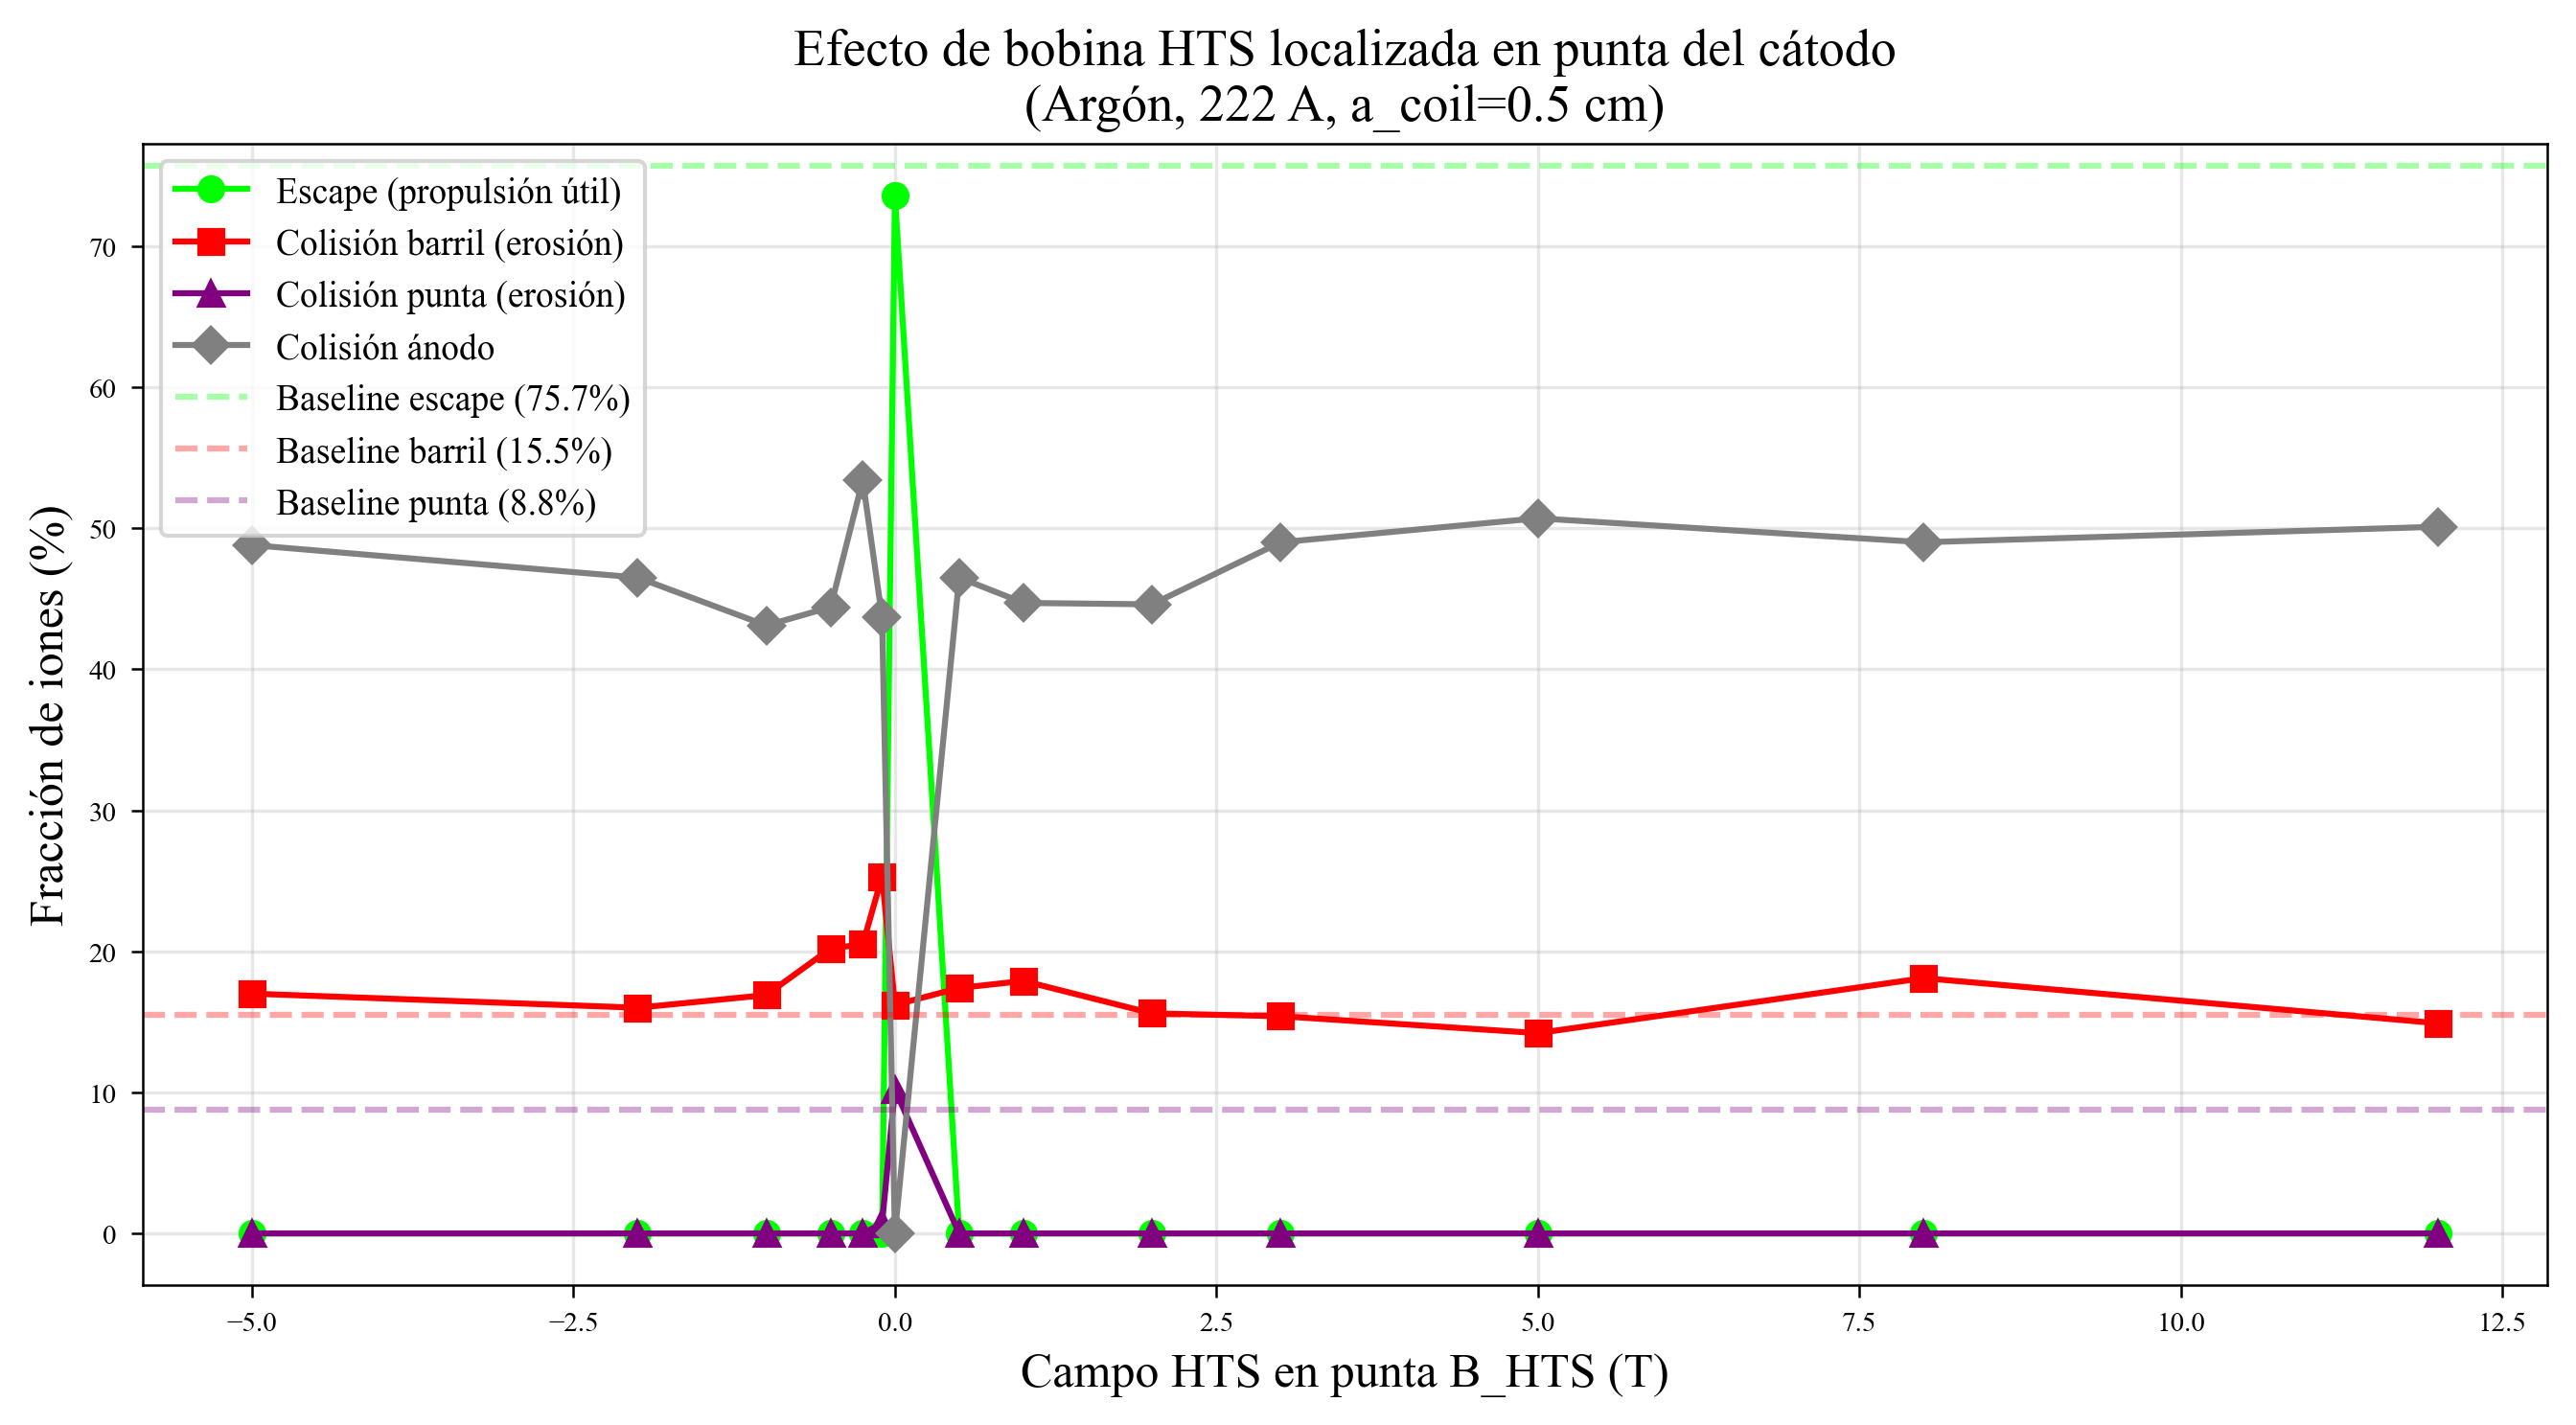


B_HTS (T)    Escape %     Barril %     Punta %      Ánodo %    Δ Escape
--------------------------------------------------------------------
-5.0         0.0          17.0         0.0          48.8       -75.7%
-2.0         0.0          16.0         0.0          46.5       -75.7%
-1.0         0.0          16.9         0.0          43.1       -75.7%
-0.5         0.0          20.2         0.0          44.4       -75.7%
-0.2         0.0          20.5         0.0          53.4       -75.7%
-0.1         0.0          25.3         0.7          43.7       -75.7%
0.0          73.6         16.2         10.2         0.0        -2.1%
0.5          0.0          17.4         0.0          46.5       -75.7%
1.0          0.0          17.9         0.0          44.7       -75.7%
2.0          0.0          15.6         0.0          44.6       -75.7%
3.0          0.0          15.4         0.0          49.0       -75.7%
5.0          0.0          14.2         0.0          50.7       -75.7%
8.0          0.0   

In [ ]:

from tqdm.notebook import tqdm

carga_e = 1.602e-19
n_e = 2.27e19

def campo_bobina_localizada(R, Z, B_peak, z_bobina, a_coil):
    """Campo de una bobina concentrada en z_bobina. Unidades: cm y Tesla."""
    dz = Z - z_bobina
    Bz_loc = B_peak / np.power(1.0 + np.power(dz / a_coil, 2), 1.5)
    dBz_dz = -3.0 * B_peak * dz / (a_coil**2 * np.power(1.0 + np.power(dz / a_coil, 2), 2.5))
    Br_loc = -0.5 * R * dBz_dz
    return Bz_loc, Br_loc

def correr_simulacion_HTS(B_HTS, n_pasos=900_000):
    a_coil_global = 4.0   # cm - solenoide global (para Lorentz/empuje)
    a_coil_HTS   = 0.5    # cm - bobina HTS concentrada en la punta
    B0_global    = 0.0    # T  - campo global fijo (punto óptimo del barrido anterior)


    Er_local = np.zeros_like(R)
    Ez_local = np.zeros_like(R)

    dr_celda_cm    = r_a_max / (Nr - 1)
    radio_atraccion = r_c + (3.0 * dr_celda_cm)

    mascara_vaina = (Z >= 0.1) & (Z <= L_c) & (R >= r_c) & (R <= radio_atraccion)
    Er_local[mascara_vaina] = -0.5 * (1.0 - (Z[mascara_vaina] / L_c))

    mascara_punta_ez = (Z >= L_c) & (Z <= L_a) & (R <= r_c)
    Ez_local[mascara_punta_ez] = -10.0

    Bz_g   = B0_global / np.power(1.0 + np.power(Z / a_coil_global, 2), 1.5)
    dBz_dz = -3.0 * B0_global * Z / (a_coil_global**2 * np.power(1.0 + np.power(Z / a_coil_global, 2), 2.5))
    Br_g   = -0.5 * R * dBz_dz

    lorentz_local = motor_mpd_cpp.FuerzaLorentz(Nr, Nz)
    lorentz_local.calcular_tensores(corriente_A, Parametro_Hall, L_c, R, Z,
                                    np.ascontiguousarray(Br_g),
                                    np.ascontiguousarray(Bz_g))
    Fz_b = np.nan_to_num(lorentz_local.Fz)
    Fr_b = np.nan_to_num(lorentz_local.Fr)

    factor = 1.0 / (carga_e * n_e)
    mascara_empuje = (Z >= 0.0) & (Z <= L_c) & (R >= radio_atraccion) & (R <= r_a_base)
    Ez_local[mascara_empuje] = Fz_b[mascara_empuje] * factor
    Er_local[mascara_empuje] = Fr_b[mascara_empuje] * factor



    delta_z   = 1     # cm - separación entre las dos bobinas
    a_coil_HTS = 1.5     # cm - bobinas más concentradas para el cusp

    Bz_1, Br_1 = campo_bobina_localizada(R, Z, +B_HTS, L_c - delta_z, a_coil_HTS)
    Bz_2, Br_2 = campo_bobina_localizada(R, Z, -B_HTS, L_c + delta_z, a_coil_HTS)

    Bz_HTS = Bz_1 + Bz_2  
    Br_HTS = Br_1 + Br_2


    solver_local = motor_mpd_cpp.SimuladorPIC(N_iones, Te_eV, r_c, r_a_max, L_c, L_a, Nr)
    solver_local.inicializar_particulas(u_z_inicial, r_a_base)

    for _ in range(n_pasos):
        solver_local.avanzar_paso_temporal_boris(
            dt,
            np.ascontiguousarray(Ez_local),
            np.ascontiguousarray(Er_local),
            np.ascontiguousarray(Bz_HTS),   
            np.ascontiguousarray(Br_HTS),
            limite_pared_c, L_sim, Nz
        )

    estados = solver_local.obtener_estados()
    total   = len(estados)
    return {
        "B_HTS":  B_HTS,
        "escape": 100.0 * np.sum(estados == 3) / total,
        "barril": 100.0 * np.sum(estados == 1) / total,
        "punta":  100.0 * np.sum(estados == 2) / total,
        "anodo":  100.0 * np.sum(estados == 4) / total,
        "vivos":  100.0 * np.sum(estados == 0) / total,
    }

# --- Barrido ---
valores_B_HTS = [-5.0, -2.0, -1.0, -0.50, -0.25, -0.10, 0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]

print("Corriendo barrido HTS localizado...")
resultados_HTS = [correr_simulacion_HTS(b) for b in tqdm(valores_B_HTS)]

# --- Plot ---
B_vals   = [r["B_HTS"]  for r in resultados_HTS]
escape_p = [r["escape"] for r in resultados_HTS]
barril_p = [r["barril"] for r in resultados_HTS]
punta_p  = [r["punta"]  for r in resultados_HTS]
anodo_p  = [r["anodo"]  for r in resultados_HTS]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.plot(B_vals, escape_p, 'o-', color='lime',   label='Escape (propulsión útil)')
ax.plot(B_vals, barril_p, 's-', color='red',    label='Colisión barril (erosión)')
ax.plot(B_vals, punta_p,  '^-', color='purple', label='Colisión punta (erosión)')
ax.plot(B_vals, anodo_p,  'D-', color='gray',   label='Colisión ánodo')

# Líneas base (sin campo HTS)
base_escape, base_barril, base_punta = 75.7, 15.5, 8.8
ax.axhline(y=base_escape, color='lime',   linestyle='--', alpha=0.35, label=f'Baseline escape ({base_escape}%)')
ax.axhline(y=base_barril, color='red',    linestyle='--', alpha=0.35, label=f'Baseline barril ({base_barril}%)')
ax.axhline(y=base_punta,  color='purple', linestyle='--', alpha=0.35, label=f'Baseline punta ({base_punta}%)')

ax.set_xlabel('Campo HTS en punta B_HTS (T)', fontsize=12)
ax.set_ylabel('Fracción de iones (%)', fontsize=12)
ax.set_title('Efecto de bobina HTS localizada en punta del cátodo\n(Argón, 222 A, a_coil=0.5 cm)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Tabla con comparación vs baseline ---
print(f"\n{'B_HTS (T)':<12} {'Escape %':<12} {'Barril %':<12} {'Punta %':<12} {'Ánodo %':<10} {'Δ Escape'}")
print("-" * 68)
for r in resultados_HTS:
    delta = r["escape"] - base_escape
    signo = "+" if delta >= 0 else ""
    print(f"{r['B_HTS']:<12.1f} {r['escape']:<12.1f} {r['barril']:<12.1f} "
          f"{r['punta']:<12.1f} {r['anodo']:<10.1f} {signo}{delta:.1f}%")